# Notebook 07 — Predicted-probability and lab-missingness investigation (scaling / no_ever version)

## Purpose

This notebook examines the out-of-fold predicted probabilities from notebook 05 (scaling / no_ever version) for the four models (LR, RF, SVM, XGB), and from notebook 06 for the feed-forward ANN (no_ever feature set). It asks four questions:

1. **Pairwise ranking** — within each matched stratum, how often does the model give the case a higher probability than its own control (`pair_acc`)?
2. **Probability distribution by true class** — where do cases and controls fall relative to the 0.5 cutoff?
3. **Two groups of cases** — among true cases, what differs between those XGB scores at or above 0.6 and those below it (features, lab-measurement flags, lab deciles, raw lab values)?
4. **Missingness: between-class or within-class** — do the `_measured` flags differ more between cases and controls, or between the two groups of cases?

Sections 3–5 answer these for the four notebook-05 models, using XGB for the case split. Section 6 repeats the same analyses for the ANN.

**Inputs** (all under `PROJECT_ROOT / "data"`):

| File | Contents |
|---|---|
| `05_scaling_no_ever_preds.csv` | Out-of-fold `P(case)` per patient for LR, RF, SVM, XGB (43 features) |
| `06_ann_no_ever_preds.csv` | Out-of-fold `P(case)` per patient for the ANN (43 features) |
| `05_data_OHE.csv` | One-hot-encoded feature matrix |
| `osteo_features.csv` | Raw lab values |

Dataset: 61,026 rows, 30,513 strata, 30,513 cases and 30,513 controls.

## Table of contents

1. [Setup](#s1)
2. [Load out-of-fold predictions](#s2)
3. [Check decision threshold](#s3)
   - 3.1 [Pairwise accuracy (`pair_acc`)](#s3-1)
   - 3.2 [Predicted-probability distribution by class](#s3-2)
   - 3.3 [Probability summary by class](#s3-3)
   - 3.4 [Violin plots](#s3-4)
   - 3.5 [Observations](#s3-5)
4. [What separates the two case modes?](#s4)
   - 4.1 [Join features to predictions](#s4-1)
   - 4.2 [Split cases by XGB probability](#s4-2)
   - 4.3 [Feature comparison: high vs. low confidence](#s4-3)
   - 4.4 [Measurement-flag comparison](#s4-4)
   - 4.5 [Lab deciles among cases who had a lab draw](#s4-5)
   - 4.6 [Raw lab values among cases who had a lab draw](#s4-6)
   - 4.7 [Raw lab range within each decile](#s4-7)
5. [Is missingness between-class or within-class?](#s5)
   - 5.1 [Between-class](#s5-1)
   - 5.2 [Within-class](#s5-2)
   - 5.3 [Section summary](#s5-3)
6. [ANN investigation](#s6)
   - 6.1 [Load ANN out-of-fold predictions](#s6-1)
   - 6.2 [Pairwise accuracy — all five models](#s6-2)
   - 6.3 [Predicted-probability distribution: XGB vs. ANN](#s6-3)
   - 6.4 [Probability summary: XGB vs. ANN](#s6-4)
   - 6.5 [Violin plots: XGB vs. ANN](#s6-5)
   - 6.6 [Split cases by ANN probability](#s6-6)
   - 6.7 [Agreement between the XGB and ANN splits](#s6-7)
   - 6.8 [Feature comparison: high vs. low confidence (ANN)](#s6-8)
   - 6.9 [Measurement-flag comparison (ANN)](#s6-9)
   - 6.10 [Lab deciles among cases who had a lab draw (ANN)](#s6-10)
   - 6.11 [Raw lab values among cases who had a lab draw (ANN)](#s6-11)
   - 6.12 [Between-class vs. within-class: XGB and ANN](#s6-12)
   - 6.13 [Observations](#s6-13)
7. [Conclusion](#s7)
   - 7.1 [Four notebook-05 models](#s7-1)
   - 7.2 [ANN](#s7-2)

<a id="s1"></a>
## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODELS = ["LR", "RF", "SVM", "XGB"]

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR     = PROJECT_ROOT / "data"

PRED_FILE = DATA_DIR / "05_scaling_no_ever_preds.csv"
OHE_FILE  = DATA_DIR / "05_data_OHE.csv"
OSTEO_FEATURES = DATA_DIR / "osteo_features.csv"

<a id="s2"></a>
## 2. Load out-of-fold predictions

One row per patient. The assertion checks that every stratum has exactly two rows (one case, one control).

In [3]:
preds = pd.read_csv(PRED_FILE)

print("rows  :", len(preds))
print("strata:", preds["Strata"].nunique())
print("labels:", preds["osteo_label"].value_counts().to_dict())

assert len(preds) == 2 * preds["Strata"].nunique()

rows  : 61026
strata: 30513
labels: {0: 30513, 1: 30513}


<a id="s3"></a>
## 3. Check decision threshold

<a id="s3-1"></a>
### 3.1 Pairwise accuracy (`pair_acc`)

`pair_acc` says: for what fraction of matched pairs did the model give the case a higher probability than its own control?

Another name is `Pairwise Concordance` / `Pairwise ROC-AUC`: pair_acc is equivalent to calculating the Area Under the Receiver Operating Characteristic Curve (ROC-AUC) specifically evaluated within each matched stratum.

Using LR as example to explain the code: `LR_prob` returns one number per patient: the model's estimated probability that this patient is a case. It comes from `predict_proba` inside the fold loop in notebook 5, on the fold where that patient was held out. Every row in joined has one, whether the patient is actually a case or a control. No comparison involved — the model looks at one patient's features and outputs a number.

Then `PAIR_FRAME` reorganizes those numbers. It takes the two patients in a stratum, looks at their osteo_label, and files each one's `LR_prob` into a column named for what that patient actually is:

- the patient with `osteo_label` == 1 → their `LR_prob` becomes `case_prob`
- the patient with `osteo_label` == 0 → their `LR_prob` becomes `ctrl_prob`

Also worth noting: the names describe the true label, not the prediction. A `ctrl_prob` of 0.77 means a real control that the model scored high.

In [4]:
def PAIR_FRAME(preds, model):
    """One row per stratum: the case's probability and its matched control's."""
    wide = preds.pivot(index="Strata",
                       columns="osteo_label",
                       values=f"{model}_prob")
    wide.columns = ["ctrl_prob", "case_prob"]
    wide["margin"] = wide["case_prob"] - wide["ctrl_prob"]
    return wide


pairs = {m: PAIR_FRAME(preds, m) for m in MODELS}

# pairs[m]['margin']: turns the margin column into True/False. True where the case got the bigger number.
for m in MODELS:
    print(f"{m}: pair_acc = {(pairs[m]['margin'] > 0).mean():.4f}")

LR: pair_acc = 0.7469
RF: pair_acc = 0.7840
SVM: pair_acc = 0.7364
XGB: pair_acc = 0.7865


`.mean()` on a True/False column gives the fraction that are True, because True counts as 1 and False as 0. 

For example: Over 30,513 strata, XGB gives 0.7865.
So: in 78.65% of pairs the model gave the case a higher probability than its matched control. In the remaining 21.35% it gave the control the higher one.

This evaluation measures **pairwise ranking accuracy** (or matched pair accuracy), which tests how often each model correctly assigns a higher predicted probability to a case compared to its matched control within the same stratum.

**Key Takeaways**

**Tree-Based Models Lead**: XGBoost (0.7865) and Random Forest (0.7840) perform best, correctly ranking the case higher than its matched control in ~78.6% of strata. Their performance is virtually neck-and-neck.

**Linear/Margin Models Lag**: Logistic Regression (0.7469) and SVM (0.7364) show a ~4–5% drop in pairwise accuracy compared to the tree ensembles, suggesting non-linear feature interactions or non-linear decision boundaries are important for separating cases from controls in this dataset.

**Interpretation of Metric**: Because this metric explicitly evaluates within-stratum ranking, it directly mirrors the pairwise concordance probability (equivalent to the Area Under the ROC Curve evaluated within matched pairs). A score of 0.5000 would indicate random guessing, so all models demonstrate substantial predictive power above baseline.

    **Conclusions**

**Model Selection**: Gradient Boosting (XGB) or Random Forest (RF) should be prioritized for downstream deployment or tuning, as tree ensembles better capture the underlying structure of this matched dataset.

**Pairwise Separation**: All models demonstrate strong discriminative capacity well above baseline (>73%), confirming that model-predicted risk scores reliably distinguish cases from matched controls within the same stratum.

Distribution of `ctrl_prob`, `case_prob`, and `margin` per model:

In [5]:
for m in MODELS:
    print(m)
    print(pairs[m].describe())
    print('\n')

LR
          ctrl_prob     case_prob        margin
count  30513.000000  30513.000000  30513.000000
mean       0.397767      0.602192      0.204425
std        0.151786      0.238567      0.285293
min        0.010945      0.003650     -0.892382
25%        0.306113      0.405389     -0.000816
50%        0.399617      0.534027      0.171894
75%        0.451724      0.861473      0.447104
max        0.999012      0.999927      0.954271


RF
          ctrl_prob     case_prob        margin
count  30513.000000  30513.000000  30513.000000
mean       0.378299      0.620297      0.241999
std        0.149682      0.242310      0.286053
min        0.027819      0.043809     -0.830416
25%        0.298593      0.402504      0.017690
50%        0.366812      0.570893      0.208270
75%        0.455656      0.875008      0.482377
max        0.989251      0.998064      0.952391


SVM
          ctrl_prob     case_prob        margin
count  30513.000000  30513.000000  30513.000000
mean       0.413955      0

<a id="s3-2"></a>
### 3.2 Predicted-probability distribution by class

Histograms of predicted probability by true class show how the two classes overlap.

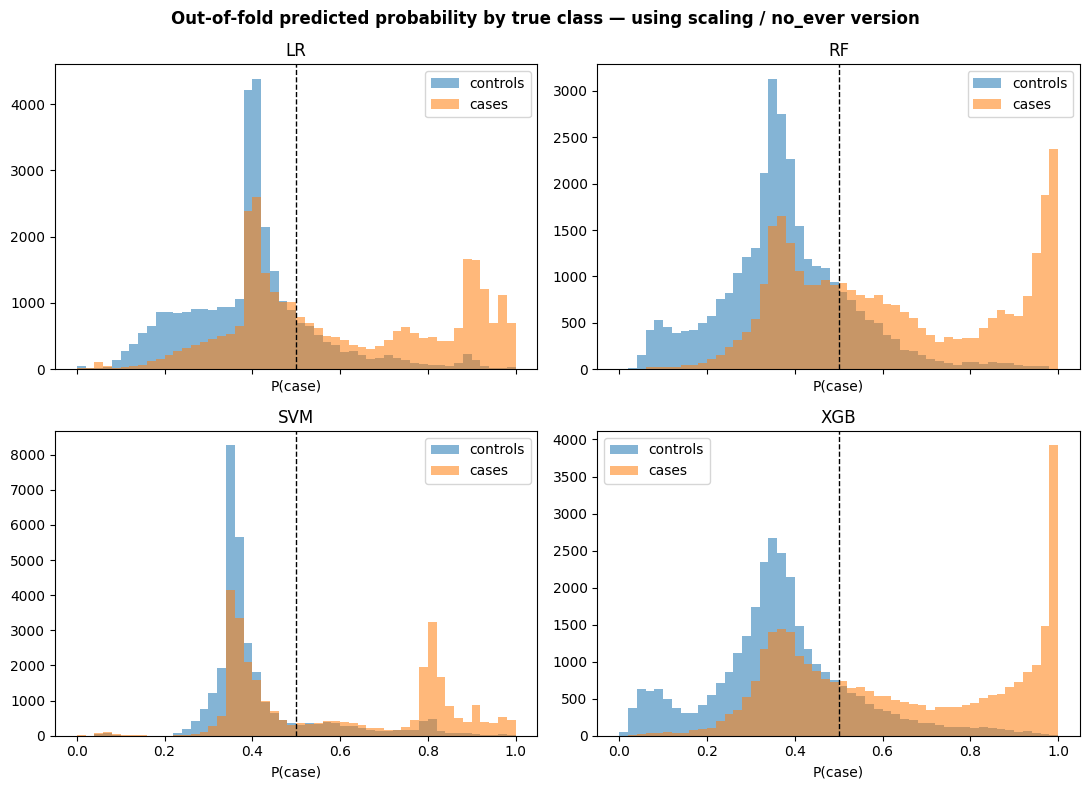

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

for ax, m in zip(axes.ravel(), MODELS):
    for label, name in [(0, "controls"), (1, "cases")]:
        ax.hist(preds.loc[preds["osteo_label"] == label, f"{m}_prob"],
                bins=50, range=(0, 1), alpha=0.55, label=name)
    ax.axvline(0.5, color="k", linestyle="--", linewidth=1)
    ax.set_title(m)
    ax.set_xlabel("P(case)")
    ax.legend()

fig.suptitle("Out-of-fold predicted probability by true class — using scaling / no_ever version",
             fontweight="bold")
fig.tight_layout()
plt.show()

The x-axis is `P(case)`, the model's output for each row. clf.predict turns that into a label by one rule: probability above 0.5 → predict case (1), below → predict control (0). The dashed line drawn at 0.5 is that rule made visible. So a row's horizontal position, relative to that line, is its prediction.

Now put the true labels back in. **Color is truth** — orange rows are actually cases, blue rows are actually controls. Position is the prediction. So each of the four combinations is a cell of the confusion matrix:

- orange, right of line → true case, predicted case → correct or `TP`
- orange, left of line → true case, predicted control → miss or `FN`
- blue, left of line → true control, predicted control → correct or `TN`
- blue, right of line → true control, predicted case → false alarm or `FP`

- `Case recall` is the orange mass right of the line divided by all orange mass.
- `Control recall` is the blue mass left of the line divided by all blue mass.

`Controls` form one tight **unimodal** cluster around 0.35–0.40. `Cases` split into two groups: one overlapping the `control` cluster almost exactly, and a second at the high end — 0.9+ in LR and XGB, 0.8 in SVM, pinned at 1.0 in RF.

<a id="s3-3"></a>
### 3.3 Probability summary by class

In [7]:
summary = []
for m in MODELS:
    for label, name in [(1, "cases"), (0, "controls")]:
        p = preds.loc[preds["osteo_label"] == label, f"{m}_prob"]
        summary.append({"model": m, "class": name,
                        "median": p.median(),
                        "q25": p.quantile(0.25),
                        "q75": p.quantile(0.75),
                        "frac_above_0.5": (p > 0.5).mean()})

print(pd.DataFrame(summary).set_index(["model", "class"]).round(3))

                median    q25    q75  frac_above_0.5
model class                                         
LR    cases      0.534  0.405  0.861           0.542
      controls   0.400  0.306  0.452           0.170
RF    cases      0.571  0.403  0.875           0.599
      controls   0.367  0.299  0.456           0.176
SVM   cases      0.521  0.370  0.808           0.512
      controls   0.366  0.350  0.416           0.162
XGB   cases      0.587  0.394  0.909           0.593
      controls   0.358  0.284  0.443           0.169


<a id="s3-4"></a>
### 3.4 Violin plots

XGB alone, then all four models side by side.

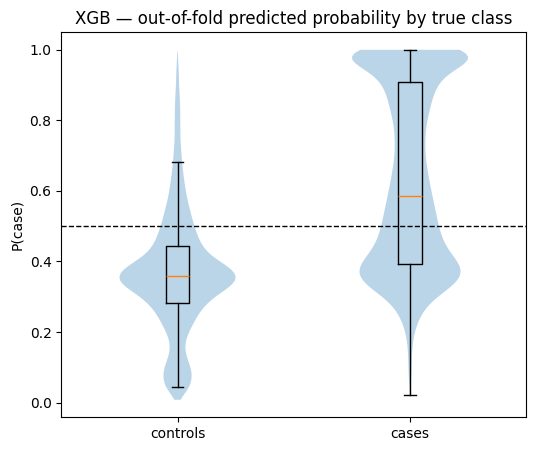

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

groups = [preds.loc[preds["osteo_label"] == 0, "XGB_prob"],
          preds.loc[preds["osteo_label"] == 1, "XGB_prob"]]

parts = ax.violinplot(groups, showextrema=False)
ax.boxplot(groups, widths=0.1, showfliers=False)

ax.set_xticks([1, 2])
ax.set_xticklabels(["controls", "cases"])
ax.set_ylabel("P(case)")
ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
ax.set_title("XGB — out-of-fold predicted probability by true class")

plt.show()

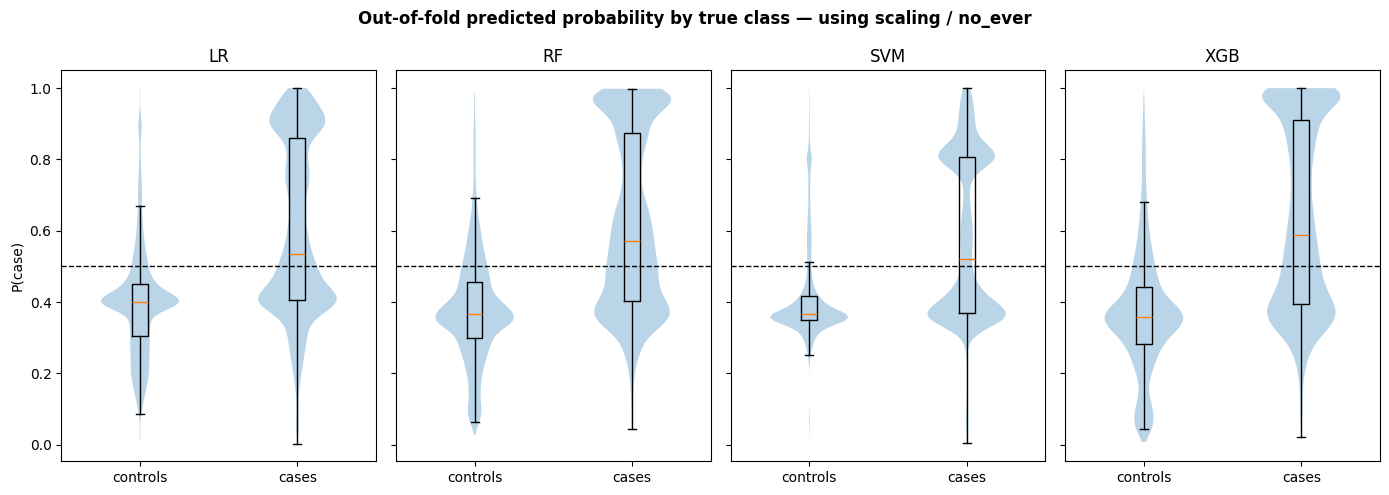

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)

for ax, m in zip(axes, MODELS):
    groups = [preds.loc[preds["osteo_label"] == 0, f"{m}_prob"],
              preds.loc[preds["osteo_label"] == 1, f"{m}_prob"]]

    ax.violinplot(groups, showextrema=False)
    ax.boxplot(groups, widths=0.1, showfliers=False)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["controls", "cases"])
    ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
    ax.set_title(m)

axes[0].set_ylabel("P(case)")
fig.suptitle("Out-of-fold predicted probability by true class — using scaling / no_ever",
             fontweight="bold")
fig.tight_layout()
plt.show()

<a id="s3-5"></a>
### 3.5 Observations

> The cases are bimodal in every model. The controls are not.
>
> What we have is a subgroup of cases the models identify confidently and a subgroup they can't distinguish from controls at all.

<a id="s4"></a>
## 4. What separates the two case modes?

<a id="s4-1"></a>
### 4.1 Join features to predictions

In [10]:
probs = [f"{m}_prob" for m in MODELS]
print(preds[probs])

        LR_prob   RF_prob  SVM_prob  XGB_prob
0      0.388075  0.411468  0.350582  0.406913
1      0.385053  0.366629  0.346666  0.373803
2      0.392603  0.409113  0.366122  0.404948
3      0.520225  0.450823  0.411164  0.468966
4      0.770783  0.569091  0.770909  0.771894
...         ...       ...       ...       ...
61021  0.809451  0.630349  0.657561  0.816994
61022  0.332481  0.467732  0.560151  0.422588
61023  0.388368  0.326922  0.350735  0.334260
61024  0.369457  0.451662  0.354943  0.481590
61025  0.480282  0.499825  0.406893  0.496347

[61026 rows x 4 columns]


In [11]:
data_OHE = pd.read_csv(OHE_FILE)

FEATURE_COLS = [c for c in data_OHE.columns
                if c not in ("Strata", "osteo_label")]

joined = data_OHE.merge(
    preds[["Strata", "osteo_label"] + [f"{m}_prob" for m in MODELS]],
    on=["Strata", "osteo_label"],
    validate="one_to_one",
)

print(joined.shape, len(FEATURE_COLS), "features")

(61026, 55) 49 features


<a id="s4-2"></a>
### 4.2 Split cases by XGB probability

In [13]:
MODEL = "XGB"
CUT   = 0.6          # the trough between the two case modes

cases = joined[joined["osteo_label"] == 1].copy()
cases["mode"] = np.where(cases[f"{MODEL}_prob"] >= CUT, "high confidence", "low confidence") #high mean the model confident about its prediction

print(cases["mode"].value_counts().to_dict())

{'low confidence': 15615, 'high confidence': 14898}


<a id="s4-3"></a>
### 4.3 Feature comparison: high vs. low confidence - highlighting the features that drive strong model certainty

- Top 15 features by absolute difference in group means (`_Ever` columns excluded).
- "confidence" here means the model confidence on its prediction, measure by P(case) > 0.6, highlighting the features that drive strong model certainty

In [15]:
FEATURE_COLS = [c for c in data_OHE.columns
                if c not in ("Strata", "osteo_label")
                and "_Ever" not in c]

#among the cases that XGB predicted
compare = (cases.groupby("mode")[FEATURE_COLS]
                .mean()
                .T
                .assign(diff=lambda d: d["high confidence"] - d["low confidence"]))

print(compare.reindex(compare["diff"].abs().sort_values(ascending=False).index)
             .head(15).round(3))

mode                            high confidence  low confidence   diff
Calcium_Avg_Prior_decile                  2.050           3.082 -1.032
Calcium_Closest_Osteo_decile              2.023           2.837 -0.814
BMI_Avg                                  27.225          27.961 -0.736
Sodium_Closest_Osteo_decile               2.820           2.437  0.383
Calcium_Closest_Osteo_measured            0.386           0.624 -0.238
Calcium_Avg_Prior_measured                0.410           0.619 -0.209
Sodium_Closest_Osteo_measured             0.828           0.624  0.204
Sodium_Avg_Prior_decile                   3.074           2.910  0.163
Hyponatremia_Prior                        0.230           0.092  0.138
Sodium_Worst_Prior_measured               0.754           0.619  0.135
Sodium_Avg_Prior_measured                 0.754           0.619  0.135
Chronic_Hyponatremia                      0.133           0.013  0.120
Recent_Hyponatremia                       0.148           0.030  0.118
Drug_O

Split the `cases` that XGB predicted into two groups by predicted probability — 14,898 "high" and 15,615 "low". Read the two columns:

Among the top 15 features, exclusing calcium/sodium values (as will dive into details later) and BMI_Avg (which had little effect on the published association in the paper with adjusted odds ratio): 

 * **Hyponatremia and opiates:** Hyponatremia flags (`Chronic_Hyponatremia`: 13.3% vs. 1.3%) and prior opiate use (`Drug_Opiates_prior`: 16.7% vs. 5.7%) are more common in high-confidence cases.

Among calcium/sodium values: 

Sodium measured in `Sodium_Closest_Osteo_measured`: high 0.828, low 0.624. 
- Among cases the model scores confidently, 83% had a sodium drawn.
- Among cases it can't distinguish from controls, 62% did.
  
Calcium measured in `Calcium_Closest_Osteo_measured`: high 0.386, low 0.624. Only 39% of the confident group had a calcium drawn, versus 62% of the other group.

> the thing distinguishing these two groups of cases is which tests a clinician ordered, not what the results were.

<a id="s4-4"></a>
### 4.4 Measurement-flag comparison

This section zooms into `_measured` cols

In [16]:
MEASURED_COLS = [c for c in data_OHE.columns
                 if c.endswith("_measured")
                 and "_Ever" not in c]

compare_measured = (cases.groupby("mode")[MEASURED_COLS]
                         .mean()
                         .T
                         .assign(diff=lambda d: d["high confidence"] - d["low confidence"]))

print(compare_measured.reindex(
          compare_measured["diff"].abs().sort_values(ascending=False).index)
      .round(3))

mode                            high confidence  low confidence   diff
Calcium_Closest_Osteo_measured            0.386           0.624 -0.238
Calcium_Avg_Prior_measured                0.410           0.619 -0.209
Sodium_Closest_Osteo_measured             0.828           0.624  0.204
Sodium_Avg_Prior_measured                 0.754           0.619  0.135
Sodium_Worst_Prior_measured               0.754           0.619  0.135


> Calcium is measured less often in the high-confidence cases
> 
> Sodium is measured more often in high-confidence cases

The low-confidence column is nearly constant. 0.624, 0.619, 0.624, 0.619, 0.619 across all five. Whatever the ordering process is, the cases the model can't identify look the same on every measurement flag — roughly 62% have each test. The high-confidence column is the one that varies, from 0.386 up to 0.828.

Two sodium columns are identical. `Sodium_Avg_Prior_measured` and `Sodium_Worst_Prior_measured` match to three decimals in both groups (0.754 / 0.619). Both derive from the same prior-window sodium draws, so a patient with any prior sodium has both an average and a worst — **they're the same flag under two names.** That's a redundant feature pair, and worth checking Multicollinearity since it means one of them carries no information the other doesn't.

#### 4.4.A Missingness in the encoding

How the decile column behaves when the lab was not measured:

In [17]:
print(joined.groupby("Calcium_Avg_Prior_measured")["Calcium_Avg_Prior_decile"]
            .describe().round(3))

                              count   mean    std  min  25%  50%  75%  max
Calcium_Avg_Prior_measured                                                
0                           25388.0  0.000  0.000  0.0  0.0  0.0  0.0  0.0
1                           35638.0  4.468  2.849  0.0  2.0  4.0  7.0  9.0


> Missing labs are coded as decile 0, so **lab deciles mix "not measured" with low values. (as show in min =0 for both measure and no measure)**

> section 4.4.A showed unmeasured labs are coded as decile 0, so **those columns mixed "no lab drawn" with "low value."**
> 
> Thus, section 4.3 and 4.4 is not fully accurate. Solution: Restricting to _measured == 1 removes the 0-coding and leaves only patients who actually had a draw.

<a id="s4-5"></a>
### 4.5 <u>Lab deciles</u> _among cases_ who had a lab draw

In [18]:
DECILES = [c for c in FEATURE_COLS if c.endswith("_decile")]

for col in DECILES:
    flag = col.replace("_decile", "_measured")
    sub = cases[cases[flag] == 1]
    g = sub.groupby("mode")[col].mean()
    print(f"{col:36s} high {g['high confidence']:.3f}  low {g['low confidence']:.3f}  "
          f"diff {g['high confidence'] - g['low confidence']:+.3f}")

Calcium_Closest_Osteo_decile         high 5.244  low 4.550  diff +0.694
Sodium_Closest_Osteo_decile          high 3.406  low 3.904  diff -0.498
Calcium_Avg_Prior_decile             high 5.003  low 4.977  diff +0.026
Sodium_Avg_Prior_decile              high 4.078  low 4.701  diff -0.622
Sodium_Worst_Prior_decile            high 3.421  low 4.341  diff -0.920


**Update read from section 4.3**

The calcium difference does not survive. For `Calcium_Avg_Prior_decile`, the gap goes from −1.032 in 4.3 to +0.026 in 4.5: 5.003 vs. 4.977, essentially nothing. So the largest single feature difference in 4.3 was the missingness code, not the calcium values.

<a id="s4-6"></a>
### 4.6 <u>Raw lab values</u> among cases who had a lab draw

Load the raw lab values, merge them onto `joined`, and rebuild `cases`.

In [19]:
osteo_features = pd.read_csv(OSTEO_FEATURES)
osteo_features.shape

/var/folders/dq/3x7mwtv514n94gkw_yqvzj040000gn/T/ipykernel_8452/2658473009.py:1: DtypeWarning: Columns (0: First_Chemo_agent_date) have mixed types. Specify dtype option on import or set low_memory=False.
  osteo_features = pd.read_csv(OSTEO_FEATURES)


(61026, 203)

In [20]:
RAW_LABS = ["Calcium_Avg_Prior",    "Calcium_Closest_Osteo",
             "Sodium_Worst_Prior", "Sodium_Avg_Prior", "Sodium_Closest_Osteo"
           ]

raw = pd.read_csv(OSTEO_FEATURES, usecols=["Strata", "osteo_label"] + RAW_LABS)

print(raw.shape)
print(raw.duplicated(["Strata", "osteo_label"]).sum(), "duplicate keys")

(61026, 7)
0 duplicate keys


In [21]:
joined = joined.merge(raw, on=["Strata", "osteo_label"], validate="one_to_one")
print(joined.shape)

(61026, 60)


In [23]:
joined = joined.drop(columns=[c for c in joined.columns if c.endswith("_y")])
joined.columns = [c[:-2] if c.endswith("_x") else c for c in joined.columns]

print(joined.shape)

(61026, 60)


In [24]:
# cases was built from joined BEFORE the raw labs were merged in, so rebuild it
cases = joined[joined["osteo_label"] == 1].copy()
cases["mode"] = np.where(cases[f"{MODEL}_prob"] >= CUT, "high confidence", "low confidence")

for col in RAW_LABS:
    sub = cases[cases[f"{col}_measured"] == 1]
    g = sub.groupby("mode")[col]
    print(f"\n=== {col} ===")
    print(g.agg(["count", "mean", "median", "std"]).round(2))


=== Calcium_Avg_Prior ===
                 count  mean  median   std
mode                                      
high confidence   6105  9.13    9.15  0.83
low confidence    9670  9.10    9.17  0.68

=== Calcium_Closest_Osteo ===
                 count  mean  median   std
mode                                      
high confidence   5747  9.27     9.3  1.27
low confidence    9736  9.06     9.2  0.78

=== Sodium_Worst_Prior ===
                 count    mean  median    std
mode                                         
high confidence  11228  136.37   137.0  11.24
low confidence    9668  137.81   138.0   4.49

=== Sodium_Avg_Prior ===
                 count    mean  median    std
mode                                         
high confidence  11228  139.02   139.4  10.74
low confidence    9668  139.75   140.0   3.58

=== Sodium_Closest_Osteo ===
                 count    mean  median    std
mode                                         
high confidence  12333  138.59   139.0  10.59
low conf

<a id="s4-7"></a>
### 4.7 Raw lab range within each decile

Only patients with a lab draw (`_measured == 1`).

In [25]:
for col in RAW_LABS:
    dec = f"{col}_decile"
    # only patients with a lab draw (_measured == 1); unmeasured patients are excluded
    g = joined[joined[f"{col}_measured"] == 1].groupby(dec)[col]
    print(f"\n=== {col} ===")
    print(g.agg(["count", "min", "mean", "max"]).round(2))


=== Calcium_Avg_Prior ===
                          count   min   mean    max
Calcium_Avg_Prior_decile                           
0                          3564  0.75   6.17   7.78
1                          3564  7.78   8.10   8.35
2                          3574  8.35   8.50   8.64
3                          3560  8.64   8.76   8.87
4                          3559  8.87   8.96   9.05
5                          3723  9.06   9.14   9.20
6                          4207  9.20   9.32   9.40
7                          2760  9.40   9.50   9.58
8                          3725  9.58   9.69   9.80
9                          3402  9.80  10.17  37.40

=== Calcium_Closest_Osteo ===
                              count   min   mean   max
Calcium_Closest_Osteo_decile                          
0                              3631   0.6   4.46   7.8
1                              4434   7.9   8.19   8.4
2                              3833   8.5   8.61   8.7
3                              3217   8.8  

<a id="s5"></a>
## 5. Is missingness between-class or within-class?

This section investigates whether missingness in lab measurements is a between-class effect (cases vs. controls) or a within-class effect (high-confidence cases vs. low-confidence cases),

<a id="s5-1"></a>
### 5.1 Between-class

Split by `osteo_label`: all cases in one group, all controls in the other.

**Question: do cases get different labs ordered than controls?**

In [26]:
MEASURED = [c for c in FEATURE_COLS if c.endswith("_measured")]

between = joined.groupby("osteo_label")[MEASURED].mean().T
between.columns = ["controls", "cases"]
between["diff"] = between["cases"] - between["controls"]

between = between.sort_index()

between = between.reindex(
    sorted(between.index, key=lambda c: (c.split("_")[0], c))
)

print(between.round(3))

                                controls  cases   diff
Calcium_Avg_Prior_measured         0.651  0.517 -0.134
Calcium_Closest_Osteo_measured     0.658  0.507 -0.151
Sodium_Avg_Prior_measured          0.663  0.685  0.022
Sodium_Closest_Osteo_measured      0.672  0.724  0.052
Sodium_Worst_Prior_measured        0.663  0.685  0.022


> **Between-class observation**: the signal is real but weak. Calcium is drawn less often in cases (0.51 vs 0.66) and sodium slightly more (0.72 vs 0.67). No single flag separates cases from controls.

<a id="s5-2"></a>
### 5.2 Within-class

- Within-class — throw the controls away entirely. Take only the cases, and split those by whether XGB scored them above or below 0.6. 
- Question: **among patients who are all cases, do the ones the model recognizes get different labs than the ones it misses?**

In [27]:
within = cases.groupby("mode")[MEASURED].mean().T
within["diff"] = within["high confidence"] - within["low confidence"]

within = within.sort_index()

print(within.round(3))

mode                            high confidence  low confidence   diff
Calcium_Avg_Prior_measured                0.410           0.619 -0.209
Calcium_Closest_Osteo_measured            0.386           0.624 -0.238
Sodium_Avg_Prior_measured                 0.754           0.619  0.135
Sodium_Closest_Osteo_measured             0.828           0.624  0.204
Sodium_Worst_Prior_measured               0.754           0.619  0.135


> **Within-class observation**: the same five flags, but the gaps are larger — 0.135 to 0.238, roughly 1.5× the between-class gaps, and in the same directions. So the measurement flags carry more information about which cases the model can identify than about whether a patient is a case.

<a id="s5-3"></a>
### 5.3 Section summary

**Missingness is within-class structure, not between-class.**

**Between-class (cell above): real but weak.** Calcium is drawn *less* often in cases
(0.51 vs. 0.66) and sodium slightly *more* (0.72 vs. 0.67). Gaps of 0.02–0.15. No single
flag separates cases from controls.

**Within-class: same five flags, larger gaps.** 0.135–0.238, roughly 1.5x the
between-class gaps, in the same directions. The measurement flags carry more information
about *which cases the model can identify* than about *whether a patient is a case*.

<a id="s6"></a>
## 6. ANN investigation

Sections 3–5 repeated for the feed-forward ANN from notebook 06. Earlier sections are not modified; every variable created here carries an `ann` suffix or prefix so that `cases`, `compare`, `within` etc. from sections 4–5 keep their XGB meaning.

<a id="s6-1"></a>
### 6.1 Load ANN out-of-fold predictions

The ANN predictions must come from the **43-feature (`NO_EVER_COLS`)** run in notebook 06, the same feature set as `05_scaling_no_ever_preds.csv`.

In [28]:
ANN_PRED_FILE = DATA_DIR / "06_ann_no_ever_preds.csv"

ann_preds = pd.read_csv(ANN_PRED_FILE)

print("rows  :", len(ann_preds))
print("strata:", ann_preds["Strata"].nunique())
print("labels:", ann_preds["osteo_label"].value_counts().to_dict())
print("missing ANN_prob:", ann_preds["ANN_prob"].isna().sum())

assert len(ann_preds) == 2 * ann_preds["Strata"].nunique()
assert ann_preds["ANN_prob"].notna().all()

rows  : 61026
strata: 30513
labels: {0: 30513, 1: 30513}
missing ANN_prob: 0


In [29]:
# add ANN_prob to both frames used above
preds = preds.merge(ann_preds[["Strata", "osteo_label", "ANN_prob"]],
                    on=["Strata", "osteo_label"], validate="one_to_one")

joined = joined.merge(ann_preds[["Strata", "osteo_label", "ANN_prob"]],
                      on=["Strata", "osteo_label"], validate="one_to_one")

print("preds :", preds.shape)
print("joined:", joined.shape)

preds : (61026, 11)
joined: (61026, 61)


<a id="s6-2"></a>
### 6.2 Pairwise accuracy — all five models

Same `PAIR_FRAME` as section 3.1.

In [30]:
MODELS_ALL = MODELS + ["ANN"]

pairs["ANN"] = PAIR_FRAME(preds, "ANN")

for m in MODELS_ALL:
    print(f"{m:4s}: pair_acc = {(pairs[m]['margin'] > 0).mean():.4f}")

LR  : pair_acc = 0.7469
RF  : pair_acc = 0.7840
SVM : pair_acc = 0.7364
XGB : pair_acc = 0.7865
ANN : pair_acc = 0.7736


In [31]:
print(pairs["ANN"].describe())

          ctrl_prob     case_prob        margin
count  30513.000000  30513.000000  30513.000000
mean       0.375563      0.619528      0.243965
std        0.159780      0.252656      0.300173
min        0.021467      0.045768     -0.793122
25%        0.284138      0.382063      0.005809
50%        0.355344      0.573833      0.211827
75%        0.454284      0.897414      0.505889
max        0.984506      0.998615      0.948187


<a id="s6-3"></a>
### 6.3 Predicted-probability distribution: XGB vs. ANN

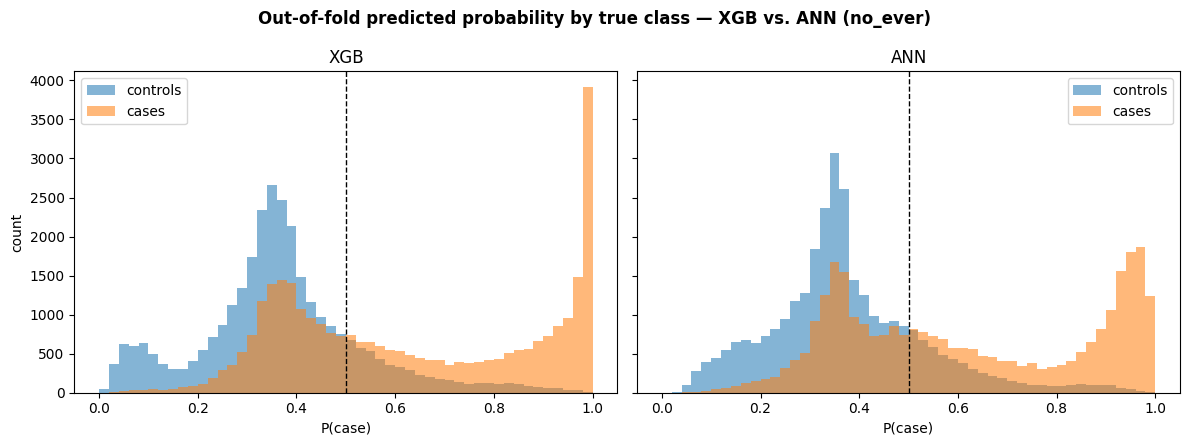

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, m in zip(axes, ["XGB", "ANN"]):
    for label, name in [(0, "controls"), (1, "cases")]:
        ax.hist(preds.loc[preds["osteo_label"] == label, f"{m}_prob"],
                bins=50, range=(0, 1), alpha=0.55, label=name)
    ax.axvline(0.5, color="k", linestyle="--", linewidth=1)
    ax.set_title(m)
    ax.set_xlabel("P(case)")
    ax.legend()

axes[0].set_ylabel("count")
fig.suptitle("Out-of-fold predicted probability by true class — XGB vs. ANN (no_ever)",
             fontweight="bold")
fig.tight_layout()
plt.show()

<a id="s6-4"></a>
### 6.4 Probability summary: XGB vs. ANN

Same table as section 3.3. `frac_above_0.5` is case recall for the cases row and 1 − control recall for the controls row.

In [33]:
summary_ann = []
for m in ["XGB", "ANN"]:
    for label, name in [(1, "cases"), (0, "controls")]:
        p = preds.loc[preds["osteo_label"] == label, f"{m}_prob"]
        summary_ann.append({"model": m, "class": name,
                            "median": p.median(),
                            "q25": p.quantile(0.25),
                            "q75": p.quantile(0.75),
                            "frac_above_0.5": (p > 0.5).mean()})

print(pd.DataFrame(summary_ann).set_index(["model", "class"]).round(3))

                median    q25    q75  frac_above_0.5
model class                                         
XGB   cases      0.587  0.394  0.909           0.593
      controls   0.358  0.284  0.443           0.169
ANN   cases      0.574  0.382  0.897           0.593
      controls   0.355  0.284  0.454           0.184


<a id="s6-5"></a>
### 6.5 Violin plots: XGB vs. ANN

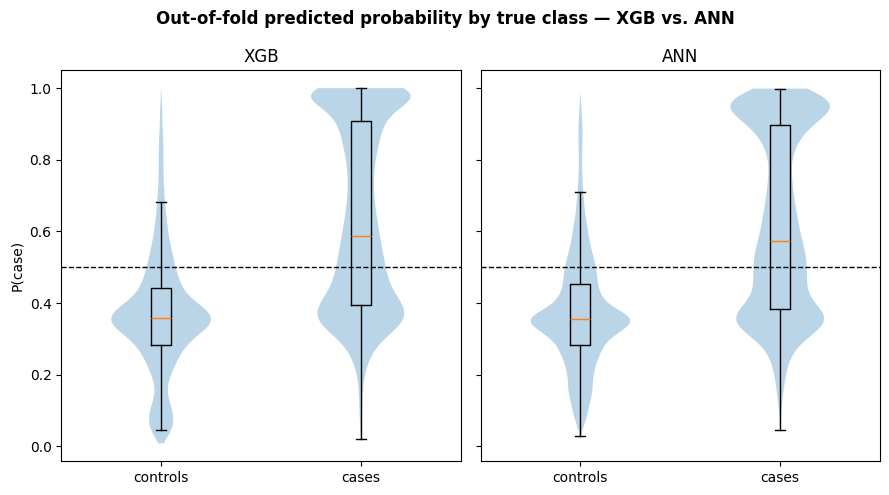

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

for ax, m in zip(axes, ["XGB", "ANN"]):
    groups = [preds.loc[preds["osteo_label"] == 0, f"{m}_prob"],
              preds.loc[preds["osteo_label"] == 1, f"{m}_prob"]]

    ax.violinplot(groups, showextrema=False)
    ax.boxplot(groups, widths=0.1, showfliers=False)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["controls", "cases"])
    ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
    ax.set_title(m)

axes[0].set_ylabel("P(case)")
fig.suptitle("Out-of-fold predicted probability by true class — XGB vs. ANN",
             fontweight="bold")
fig.tight_layout()
plt.show()

<a id="s6-6"></a>
### 6.6 Split cases by ANN probability

Same cut as the XGB split in section 4.2 (0.6), so the two splits are directly comparable. Check the case histogram in 6.3 before relying on it: 0.6 was chosen as the trough between the XGB case modes, and the ANN trough may sit elsewhere.

In [35]:
ANN_CUT = 0.6

cases_ann = joined[joined["osteo_label"] == 1].copy()
cases_ann["mode"] = np.where(cases_ann["ANN_prob"] >= ANN_CUT,
                             "high confidence", "low confidence")

print(cases_ann["mode"].value_counts().to_dict())

{'low confidence': 16010, 'high confidence': 14503}


<a id="s6-7"></a>
### 6.7 Agreement between the XGB and ANN splits

Among the same 30,513 cases: how many land in the same group under both models?

In [36]:
agree = pd.crosstab(
    np.where(cases_ann["XGB_prob"] >= CUT, "XGB high", "XGB low"),
    np.where(cases_ann["ANN_prob"] >= ANN_CUT, "ANN high", "ANN low"),
    margins=True,
)
print(agree)

same = ((cases_ann["XGB_prob"] >= CUT) == (cases_ann["ANN_prob"] >= ANN_CUT)).mean()
print(f"\nsame group under both models: {same:.3f}")
print("Spearman correlation of XGB_prob and ANN_prob among cases:",
      round(cases_ann[["XGB_prob", "ANN_prob"]].corr(method="spearman").iloc[0, 1], 3))

col_0     ANN high  ANN low    All
row_0                             
XGB high     13657     1241  14898
XGB low        846    14769  15615
All          14503    16010  30513

same group under both models: 0.932
Spearman correlation of XGB_prob and ANN_prob among cases: 0.953


93.2% of all cases are placed into the exact same categorical bin (either both low or both high) across both models: $$\frac{13,657 + 14,769}{30,513} = \frac{28,426}{30,513} \approx 0.9316 \rightarrow 0.932$$

There is a very strong monotonic relationship (0.953) between the continuous predicted probabilities (XGB_prob and ANN_prob).

In risk scoring/classification, we care primarily about whether Model A and Model B rank the subjects in the same relative order (i.e., if patient $X$ is riskier than patient $Y$ according to XGBoost, does the ANN also rank patient $X$ higher than $Y$?).

This suggests that if XGBoost assigns a higher probability to Patient A than Patient B, the Artificial Neural Network almost certainly does as well.

<a id="s6-8"></a>
### 6.8 Feature comparison: high vs. low confidence (ANN)

Same as section 4.3: top 15 features by absolute difference in group means, `_Ever` columns excluded (`FEATURE_COLS` from 4.3).

In [37]:
compare_ann = (cases_ann.groupby("mode")[FEATURE_COLS]
                        .mean()
                        .T
                        .assign(diff=lambda d: d["high confidence"] - d["low confidence"]))

print(compare_ann.reindex(compare_ann["diff"].abs().sort_values(ascending=False).index)
                 .head(15).round(3))

mode                            high confidence  low confidence   diff
Calcium_Avg_Prior_decile                  1.927           3.168 -1.241
Calcium_Closest_Osteo_decile              1.905           2.924 -1.019
BMI_Avg                                  27.238          27.931 -0.693
Sodium_Closest_Osteo_decile               2.778           2.484  0.293
Sodium_Worst_Prior_decile                 2.484           2.771 -0.287
Calcium_Closest_Osteo_measured            0.362           0.639 -0.278
Calcium_Avg_Prior_measured                0.386           0.636 -0.249
Sodium_Closest_Osteo_measured             0.817           0.639  0.178
Hyponatremia_Prior                        0.232           0.093  0.139
Recent_Hyponatremia                       0.152           0.029  0.123
Chronic_Hyponatremia                      0.135           0.013  0.122
Drug_Opiates_prior                        0.170           0.057  0.113
Sodium_Worst_Prior_measured               0.739           0.636  0.104
Sodium

<a id="s6-9"></a>
### 6.9 Measurement-flag comparison (ANN)

Same as section 4.4 (`MEASURED_COLS` from 4.4).

In [38]:
compare_measured_ann = (cases_ann.groupby("mode")[MEASURED_COLS]
                                 .mean()
                                 .T
                                 .assign(diff=lambda d: d["high confidence"] - d["low confidence"]))

print(compare_measured_ann.reindex(
          compare_measured_ann["diff"].abs().sort_values(ascending=False).index)
      .round(3))

mode                            high confidence  low confidence   diff
Calcium_Closest_Osteo_measured            0.362           0.639 -0.278
Calcium_Avg_Prior_measured                0.386           0.636 -0.249
Sodium_Closest_Osteo_measured             0.817           0.639  0.178
Sodium_Avg_Prior_measured                 0.739           0.636  0.104
Sodium_Worst_Prior_measured               0.739           0.636  0.104


<a id="s6-10"></a>
### 6.10 Lab deciles among cases who had a lab draw (ANN)

Same as section 4.5 (`DECILES` from 4.5).

In [39]:
for col in DECILES:
    flag = col.replace("_decile", "_measured")
    sub = cases_ann[cases_ann[flag] == 1]
    g = sub.groupby("mode")[col].mean()
    print(f"{col:36s} high {g['high confidence']:.3f}  low {g['low confidence']:.3f}  "
          f"diff {g['high confidence'] - g['low confidence']:+.3f}")

Calcium_Closest_Osteo_decile         high 5.266  low 4.573  diff +0.692
Sodium_Closest_Osteo_decile          high 3.400  low 3.887  diff -0.487
Calcium_Avg_Prior_decile             high 4.990  low 4.985  diff +0.005
Sodium_Avg_Prior_decile              high 4.030  low 4.721  diff -0.691
Sodium_Worst_Prior_decile            high 3.360  low 4.360  diff -0.999


<a id="s6-11"></a>
### 6.11 Raw lab values among cases who had a lab draw (ANN)

Same as section 4.6 (`RAW_LABS` from 4.6; `joined` already carries the raw values).

In [40]:
for col in RAW_LABS:
    sub = cases_ann[cases_ann[f"{col}_measured"] == 1]
    g = sub.groupby("mode")[col]
    print(f"\n=== {col} ===")
    print(g.agg(["count", "mean", "median", "std"]).round(2))


=== Calcium_Avg_Prior ===
                 count  mean  median   std
mode                                      
high confidence   5600  9.11    9.15  0.74
low confidence   10175  9.11    9.16  0.74

=== Calcium_Closest_Osteo ===
                 count  mean  median   std
mode                                      
high confidence   5246  9.27     9.3  1.29
low confidence   10237  9.07     9.1  0.80

=== Sodium_Worst_Prior ===
                 count    mean  median    std
mode                                         
high confidence  10720  136.27   137.0  11.47
low confidence   10176  137.85   138.0   4.44

=== Sodium_Avg_Prior ===
                 count    mean  median    std
mode                                         
high confidence  10720  138.95  139.33  10.98
low confidence   10176  139.79  140.00   3.52

=== Sodium_Closest_Osteo ===
                 count    mean  median    std
mode                                         
high confidence  11847  138.56   139.0  10.81
low conf

<a id="s6-12"></a>
### 6.12 Between-class vs. within-class: XGB and ANN

Between-class column is `between["diff"]` from section 5.1 (model-independent). Within-class XGB is `within["diff"]` from 5.2.

In [41]:
within_ann = cases_ann.groupby("mode")[MEASURED].mean().T
within_ann["diff"] = within_ann["high confidence"] - within_ann["low confidence"]

flag_table = pd.DataFrame({
    "between (cases - controls)": between["diff"],
    "within XGB (high - low)":    within["diff"],
    "within ANN (high - low)":    within_ann["diff"],
})

print(flag_table.round(3))

                                between (cases - controls)  \
Calcium_Avg_Prior_measured                          -0.134   
Calcium_Closest_Osteo_measured                      -0.151   
Sodium_Avg_Prior_measured                            0.022   
Sodium_Closest_Osteo_measured                        0.052   
Sodium_Worst_Prior_measured                          0.022   

                                within XGB (high - low)  \
Calcium_Avg_Prior_measured                       -0.209   
Calcium_Closest_Osteo_measured                   -0.238   
Sodium_Avg_Prior_measured                         0.135   
Sodium_Closest_Osteo_measured                     0.204   
Sodium_Worst_Prior_measured                       0.135   

                                within ANN (high - low)  
Calcium_Avg_Prior_measured                       -0.249  
Calcium_Closest_Osteo_measured                   -0.278  
Sodium_Avg_Prior_measured                         0.104  
Sodium_Closest_Osteo_measured           

<a id="s6-13"></a>
### 6.13 Observations

The features separating the groups are the same, in the same direction (6.8–6.11 against 4.3–4.6).

- Hyponatremia and opiates: the numbers are nearly identical. Chronic_Hyponatremia is 13.5% vs. 1.3% (XGB: 13.3% vs. 1.3%), and Drug_Opiates_prior is 17.0% vs. 5.7% (XGB: 16.7% vs. 5.7%).
- Measurement flags: calcium is drawn less often in high-confidence cases and sodium more often, as with XGB. For the ANN, the calcium gaps are slightly larger (−0.278 / −0.249 vs. −0.238 / −0.209) and the sodium gaps slightly smaller (+0.178 / +0.104 vs. +0.204 / +0.135).
- Low-confidence column: again nearly constant across all five flags, at 0.636–0.639 (XGB: 0.619–0.624).
- Deciles among measured cases: same signs as XGB, and Calcium_Avg_Prior is again about 0 (+0.005).
- Raw sodium: the spread shows the same contrast. The SD is 10.8–11.5 in the high group vs. 3.5–4.4 in the low group.

** Between-class vs. within-class (6.12)**

For the ANN, all five flags have the same sign as the between-class difference, and every within-class gap is larger than its between-class gap. The section 5.3 statement therefore holds for both models.

One new feature in the ANN top 15: Drug_Pp_inhibitors_prior, at 16.0% vs. 7.9% (6.8). It doesn't appear in the XGB top 15 in 4.3. That could simply be the ranking cutoff, so check its row in compare before reading anything into it.

### 6.14 Joining all 5 models

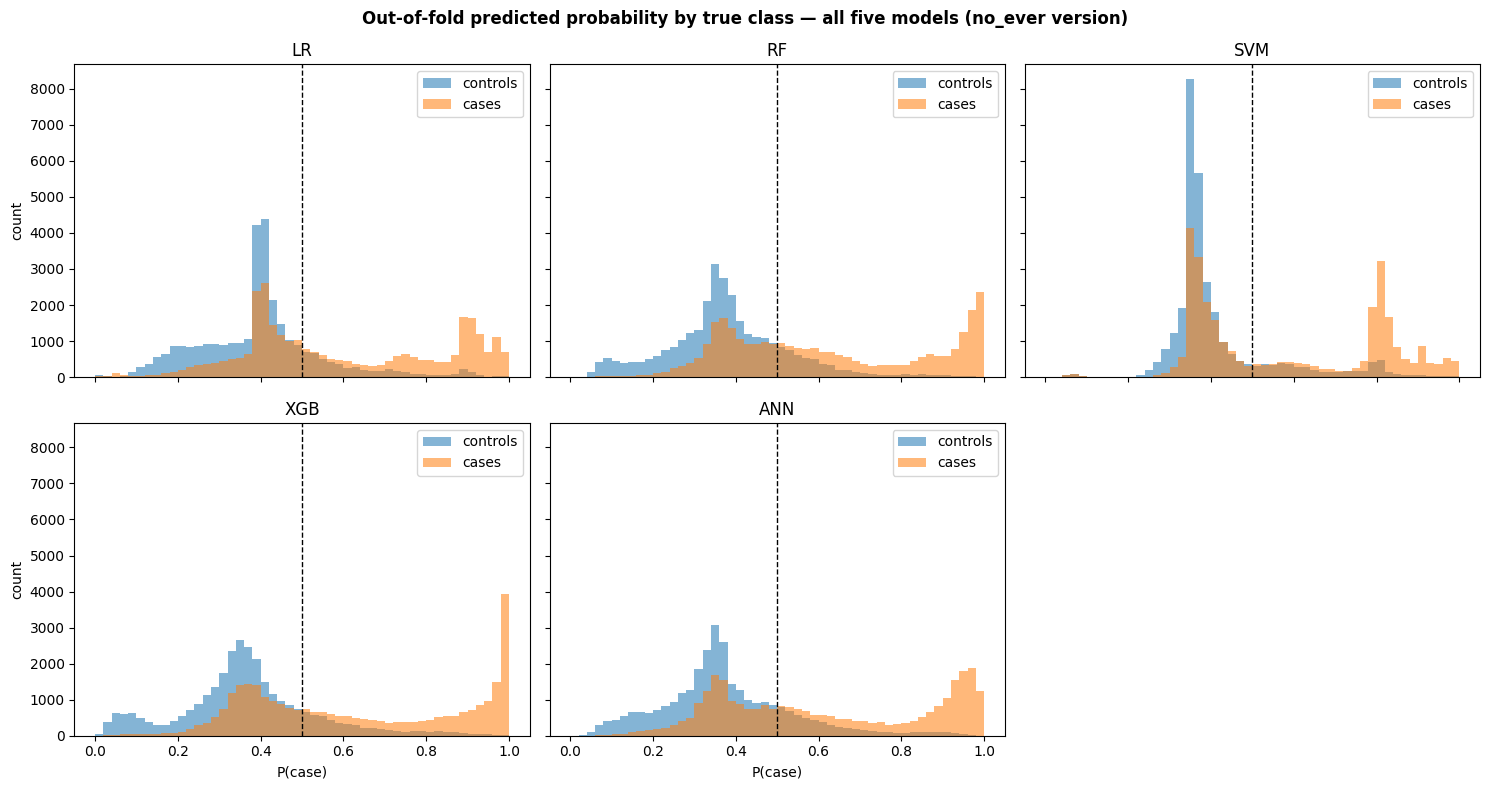

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for ax, m in zip(axes.ravel(), MODELS_ALL):
    for label, name in [(0, "controls"), (1, "cases")]:
        ax.hist(preds.loc[preds["osteo_label"] == label, f"{m}_prob"],
                bins=50, range=(0, 1), alpha=0.55, label=name)
    ax.axvline(0.5, color="k", linestyle="--", linewidth=1)
    ax.set_title(m)
    ax.legend()

axes.ravel()[-1].axis("off")          # 6th panel unused

for ax in axes[-1]:
    ax.set_xlabel("P(case)")
axes[1, 1].tick_params(labelbottom=True)   # bottom-middle panel keeps its x labels
for ax in axes[:, 0]:
    ax.set_ylabel("count")

fig.suptitle("Out-of-fold predicted probability by true class — all five models (no_ever version)",
             fontweight="bold")
fig.tight_layout()

fig.savefig(PROJECT_ROOT / "outputs" / "figures" / "prob_hist_all_5models.png", dpi=150, bbox_inches="tight")
plt.show()

**Class probability distributions**

* **Consistent controls:** Across all five models, control predictions stay predominantly below the $0.50$ decision threshold, peaking consistently around $P \approx 0.35–0.40$.

* **Bimodal case distributions (RF, XGB, ANN):** Non-linear models push a large proportion of cases toward high-confidence predictions near $P \approx 1.0$ (most pronounced in XGB). The remaining cases overlap with controls in the $0.30–0.50$ range.

* **LR vs. SVM behavior:**

    * Logistic Regression (LR): Produces a smoother distribution across the probability spectrum, with cases showing a broad secondary peak near $0.85–0.90$.
    * SVM: Highly compressed, showing a sharp concentration of both controls and cases around $0.35$, alongside a distinct secondary case peak near $0.85$.

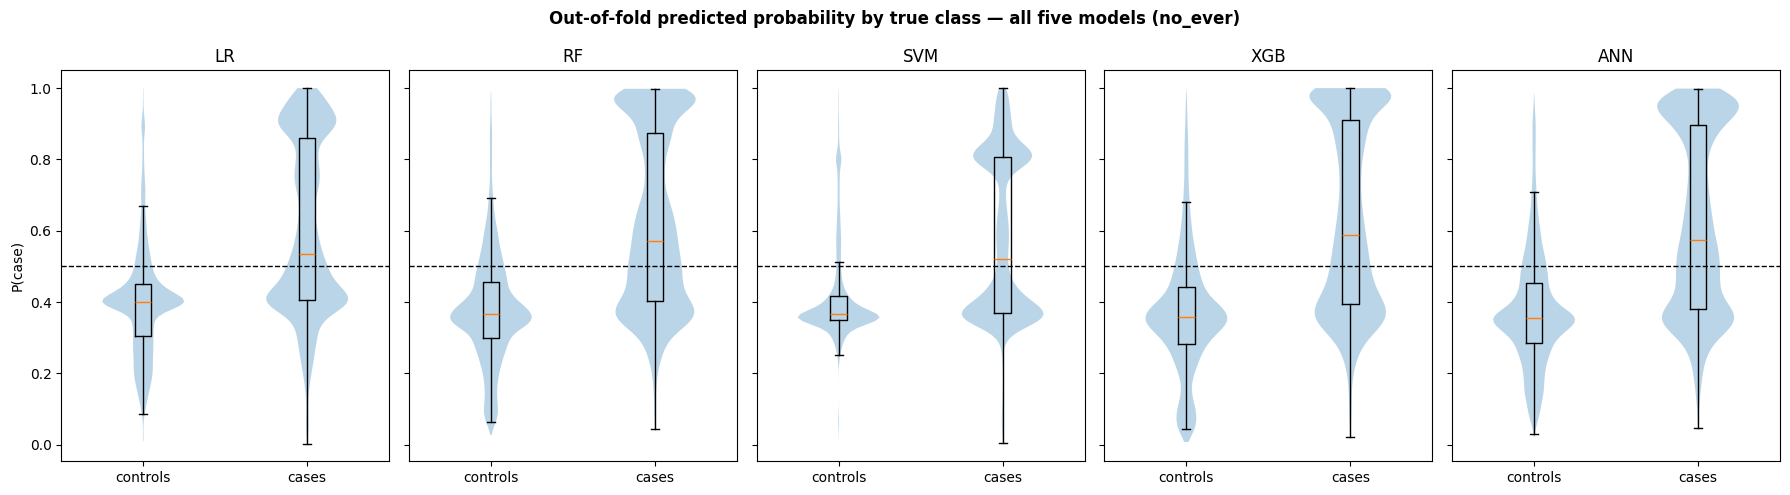

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)

for ax, m in zip(axes, MODELS_ALL):
    groups = [preds.loc[preds["osteo_label"] == 0, f"{m}_prob"],
              preds.loc[preds["osteo_label"] == 1, f"{m}_prob"]]

    ax.violinplot(groups, showextrema=False)
    ax.boxplot(groups, widths=0.1, showfliers=False)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["controls", "cases"])
    ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
    ax.set_title(m)

axes[0].set_ylabel("P(case)")
fig.suptitle("Out-of-fold predicted probability by true class — all five models (no_ever)",
             fontweight="bold")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "outputs" / "figures" / "prob_violin_all5.png", dpi=150, bbox_inches="tight")
plt.show() 

### Export confusion matrix

In [44]:
CUTOFF = 0.5

y_true = preds["osteo_label"].to_numpy()

rows = []
for m in MODELS_ALL:
    y_hat = (preds[f"{m}_prob"] >= CUTOFF).astype(int).to_numpy()

    tp = int(((y_true == 1) & (y_hat == 1)).sum())
    fn = int(((y_true == 1) & (y_hat == 0)).sum())
    tn = int(((y_true == 0) & (y_hat == 0)).sum())
    fp = int(((y_true == 0) & (y_hat == 1)).sum())

    rows.append({"model": m, "TP": tp, "FN": fn, "TN": tn, "FP": fp,
                 "case_recall": tp / (tp + fn),
                 "ctrl_recall": tn / (tn + fp),
                 "precision":   tp / (tp + fp),
                 "pred_pos_rate": (tp + fp) / len(y_true)})

cm_table = pd.DataFrame(rows).set_index("model")
print(cm_table.round(4))

          TP     FN     TN    FP  case_recall  ctrl_recall  precision  \
model                                                                   
LR     16546  13967  25325  5188       0.5423       0.8300     0.7613   
RF     18267  12246  25150  5363       0.5987       0.8242     0.7730   
SVM    15625  14888  25576  4937       0.5121       0.8382     0.7599   
XGB    18086  12427  25345  5168       0.5927       0.8306     0.7778   
ANN    18088  12425  24898  5615       0.5928       0.8160     0.7631   

       pred_pos_rate  
model                 
LR            0.3561  
RF            0.3872  
SVM           0.3369  
XGB           0.3811  
ANN           0.3884  


In [45]:
for m in MODELS_ALL:
    y_hat = (preds[f"{m}_prob"] >= CUTOFF).astype(int)
    cm = pd.crosstab(preds["osteo_label"], y_hat,
                     rownames=["true"], colnames=["predicted"])
    cm.index = ["control", "case"]
    cm.columns = ["control", "case"]
    print(f"\n=== {m} ===")
    print(cm)


=== LR ===
         control   case
control    25325   5188
case       13967  16546

=== RF ===
         control   case
control    25150   5363
case       12246  18267

=== SVM ===
         control   case
control    25576   4937
case       14888  15625

=== XGB ===
         control   case
control    25345   5168
case       12427  18086

=== ANN ===
         control   case
control    24898   5615
case       12425  18088


In [46]:
for m in MODELS:
    agree = ((preds[f"{m}_prob"] >= CUTOFF).astype(int) == preds[f"{m}_pred"]).mean()
    print(f"{m:4s}: derived label matches stored _pred: {agree:.4f}")

LR  : derived label matches stored _pred: 1.0000
RF  : derived label matches stored _pred: 1.0000
SVM : derived label matches stored _pred: 1.0000
XGB : derived label matches stored _pred: 1.0000


<a id="s7"></a>
## 7. Conclusion

<a id="s7-1"></a>
### 7.1 Four notebook-05 models

All numbers below are taken from outputs earlier in this notebook.

**Pairwise ranking (section 3.1).** Fraction of strata where the case received the higher probability: LR 0.747, RF 0.784, SVM 0.736, XGB 0.787.

**Distribution relative to 0.5 (section 3.3).** Fraction above 0.5 is 0.512–0.599 for cases and 0.162–0.176 for controls across the four models. Control medians are 0.358–0.400; case medians are 0.521–0.587.

**Two groups of cases (sections 3.2–3.5, 4.2).** The histograms show cases split into a group overlapping the controls and a group at the high end. Splitting true cases at XGB `P(case)` = 0.6 gives 14,898 high-confidence and 15,615 low-confidence cases.

**Measurement flags within cases (section 4.4).** Calcium flags are lower in the high-confidence group (0.386–0.410 vs. 0.619–0.624); sodium flags are higher (0.754–0.828 vs. 0.619–0.624). The low-confidence group sits at 0.619–0.624 on all five flags.

**Among cases who had a lab draw (sections 4.5–4.6).** Decile differences (high − low): Calcium_Closest_Osteo +0.694, Calcium_Avg_Prior +0.026, Sodium_Closest_Osteo −0.498, Sodium_Avg_Prior −0.622, Sodium_Worst_Prior −0.920. Raw means differ by at most 1.44 units; raw sodium standard deviation is 10.59–11.24 in the high-confidence group vs. 3.58–4.49 in the low-confidence group.

**Between-class vs. within-class (section 5).**

| Flag | Between-class diff (cases − controls) | Within-class diff (high − low) |
|---|---|---|
| Calcium_Avg_Prior_measured | −0.134 | −0.209 |
| Calcium_Closest_Osteo_measured | −0.151 | −0.238 |
| Sodium_Avg_Prior_measured | +0.022 | +0.135 |
| Sodium_Closest_Osteo_measured | +0.052 | +0.204 |
| Sodium_Worst_Prior_measured | +0.022 | +0.135 |

All five flags have the same sign in both comparisons, and every within-class gap is larger than the matching between-class gap.

<a id="s7-2"></a>
### 7.2 ANN

All numbers below are taken from section 6 of this notebook. The ANN was run on the same 43
features (`NO_EVER_COLS`) and the same fold assignment as the notebook-05 models.

**Pairwise ranking (6.2).** The case received the higher probability in 0.774 of strata. Among
all five models: XGB 0.787, RF 0.784, ANN 0.774, LR 0.747, SVM 0.736.

**Distribution relative to 0.5 (6.4).** Fraction above 0.5 is 0.593 for cases and 0.184 for
controls. The case median is 0.574 and the control median 0.355. XGB gives 0.593 and 0.169, with
medians 0.587 and 0.358.

**Two groups of cases (6.3, 6.6).** The histogram shows the same shape as XGB: a case group
overlapping the controls at P ≈ 0.30–0.50 and a case group at the high end, near 0.95. Splitting
true cases at ANN P(case) = 0.6 gives 14,503 high-confidence and 16,010 low-confidence cases.

**The two models split the same cases (6.7).** 93.2% of cases fall in the same group under both
models — 13,657 high in both and 14,769 low in both, with 2,087 disagreeing. The probability
rankings correlate at 0.953 (Spearman).

**Feature differences within cases (6.8).** The same features separate the two groups, in the
same direction as XGB: `Chronic_Hyponatremia` 0.135 vs. 0.013, `Recent_Hyponatremia` 0.152 vs.
0.029, `Drug_Opiates_prior` 0.170 vs. 0.057, `BMI_Avg` 27.2 vs. 27.9.

**Measurement flags within cases (6.9).** Calcium flags are lower in the high-confidence group
(0.362–0.386 vs. 0.636–0.639); sodium flags are higher (0.739–0.817 vs. 0.636–0.639). The
low-confidence group again sits flat across all five flags.

**Among cases who had a lab draw (6.10, 6.11).** Decile differences (high − low):
`Calcium_Closest_Osteo` +0.692, `Calcium_Avg_Prior` +0.005, `Sodium_Closest_Osteo` −0.487,
`Sodium_Avg_Prior` −0.691, `Sodium_Worst_Prior` −0.999. Raw sodium standard deviation is
10.81–11.47 in the high-confidence group vs. 3.52–4.44 in the low-confidence group.

**Between-class vs. within-class (6.12).** All five flags have the same sign as the XGB
within-class column, and every ANN within-class gap exceeds its between-class gap. Calcium gaps
are slightly larger than XGB's (−0.278, −0.249) and sodium gaps slightly smaller (+0.178, +0.104).

**Net.** Every result in sections 3–5 reproduces under a model with no tree structure, and the
two models score the same cases high. The case split is a property of the data, not of one
algorithm.